# Persistent (Co)homology of LEC Manifold Structure — Wake & Sleep

Tests whether LEC population activity lies on a low-dimensional **topological
manifold** (primarily a cyclic ring **S¹** reflecting the A→B→C→D→A task) and
whether it is **preserved during sleep**.

Heavy computation is done by `run_ph_batch.py` on SLURM (see
`sbatch_files/ph_lec.sbatch` / `submit_ph_lec.sh`); this notebook **loads the
cached pickles and plots**. Companion of `cyclic_structure_analysis.py` (which
tests cyclic *geometry*, not *topology*).

**Pipeline:** timepoint population vectors → smooth + z-score + PCA → max-min
landmarks → ripser H0–H2 (Z/2, Z/3) → per-neuron circular-shift shuffle null →
DREiMac circular coordinate → related to behaviour; sleep done de novo **and** by
projection onto the wake manifold.

In [1]:
# --- setup ---
import os, sys, glob
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
sys.path.insert(0, os.path.abspath('.'))
import persistent_homology_analysis as ph; reload(ph)
import glm_analysis_v2 as glm
glm.apply_gridmaze_style()

# Point at the SLURM output dir; falls back to the smoke-test dir so the
# notebook runs before the full sweep has finished.
OUT_DIR = '../data/ph_outputs'
if not glob.glob(os.path.join(OUT_DIR, '*.pkl')):
    OUT_DIR = '../data/ph_outputs_smoketest'
SAVE_DIR = '../data/ph_outputs/figures'
SAVE_FIGS = False
# per-session figure loops: cap how many sessions to plot
# (the full sweep has 100s of sessions; set higher/None-slice to see more)
MAX_PLOT = 3
print('loading from', OUT_DIR)

loading from ../data/ph_outputs


## Load results + summary table

In [2]:
results = ph.load_ph_outputs(OUT_DIR)
print(f'{len(results)} result file(s)')
df = ph.summarise(results)
df

501 result file(s)


,stem,mouse_recday,state,n_neurons,n_points,H1_top,H1_ratio,H1_p,H2_top,H2_ratio,...,replay_coverage,replay_p_continuity,replay_continuity_ratio,net_revolutions,task_phase_R,task_phase_p,goal_progress_R,goal_progress_p,head_direction_R,head_direction_p
0,ah08_20250613_20250615__sleep_sb0,ah08_20250613_20250615,sleep,151,25192,0.968730,1.041895,0.386139,0.563337,1.034329,...,0.000097,0.004975,5.452041,0.000112,NaN,NaN,NaN,NaN,NaN,NaN
1,ah08_20250613_20250615__sleep_sb1,ah08_20250613_20250615,sleep,151,12213,1.310856,1.177032,0.049505,0.511260,1.115635,...,0.000226,0.004975,5.292009,0.000102,NaN,NaN,NaN,NaN,NaN,NaN
2,ah08_20250613_20250615__sleep_sb2,ah08_20250613_20250615,sleep,151,12641,1.023584,1.026655,0.019802,0.650744,1.102599,...,0.000062,0.004975,4.648164,0.000043,NaN,NaN,NaN,NaN,NaN,NaN
3,ah08_20250613_20250615__sleep_sb3,ah08_20250613_20250615,sleep,151,12117,1.046605,1.165244,0.306931,0.619772,1.232107,...,0.000326,0.004975,5.255565,0.000121,NaN,NaN,NaN,NaN,NaN,NaN
4,ah08_20250613_20250615__sleep_sb4,ah08_20250613_20250615,sleep,151,13160,0.997042,1.166314,0.158416,0.481347,1.011918,...,0.000532,0.004975,5.486873,0.000060,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,ly07_20250624_20250625__wake_s0,ly07_20250624_20250625,wake,86,9371,1.090752,1.044663,0.039604,0.585247,1.008576,...,NaN,NaN,NaN,NaN,0.147306,0.773227,0.037749,0.266733,0.173034,0.996004
368,ly07_20250624_20250625__wake_s2,ly07_20250624_20250625,wake,86,9410,1.179022,1.528851,0.009901,0.511557,1.070538,...,NaN,NaN,NaN,NaN,0.170700,0.441558,0.030514,0.287712,0.166337,0.557443
369,ly07_20250624_20250625__wake_s3,ly07_20250624_20250625,wake,86,9202,1.149264,1.067851,0.019802,0.554645,1.118070,...,NaN,NaN,NaN,NaN,0.201874,0.937063,0.016379,0.623377,0.064465,0.301698
370,ly07_20250624_20250625__wake_s6,ly07_20250624_20250625,wake,86,10328,0.970262,1.132298,0.019802,0.640443,1.194184,...,NaN,NaN,NaN,NaN,0.084009,0.883117,0.022068,0.349650,0.069475,0.761239


In [3]:
# split wake / sleep for convenience
wake  = {k: v for k, v in results.items() if v.get('state') == 'wake'}
sleep = {k: v for k, v in results.items() if v.get('state') == 'sleep'}
print(f'wake sessions: {len(wake)}   sleep boxes: {len(sleep)}')

wake sessions: 125   sleep boxes: 247


## Fig 1 — Persistence diagrams, barcodes & significance (per wake session)

A genuine ring shows **one** H1 bar far above the rest and above the shuffle
null; H2 stays at noise. Equal-length bars (ratio ≈ 1) = topological noise.

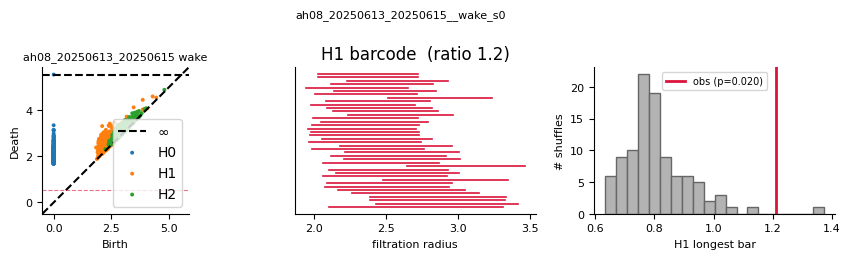

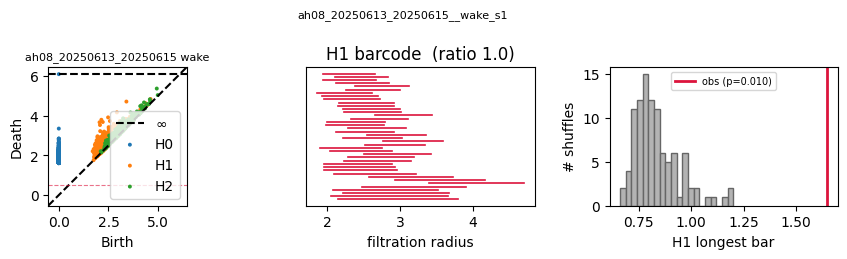

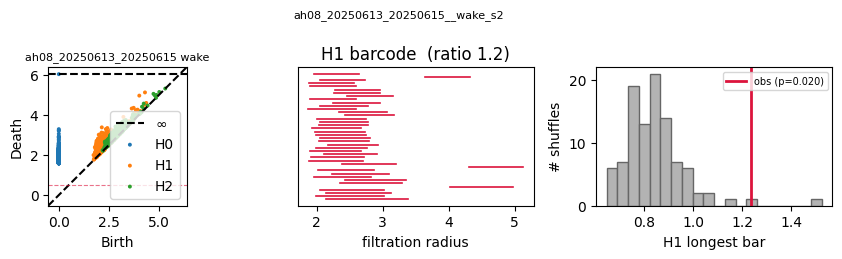

In [4]:
for stem, res in list(wake.items())[:MAX_PLOT]:
    fig, axes = plt.subplots(1, 3, figsize=(9, 2.6))
    ph.plot_persistence(res, ax=axes[0])
    ph.plot_barcode(res, dim=1, ax=axes[1])
    ph.plot_significance(res, dim=1, ax=axes[2])
    fig.suptitle(stem, fontsize=8); fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig1_persistence_'+stem, SAVE_DIR)
    plt.show()

## Fig 2 — Betti summary across sessions / mice

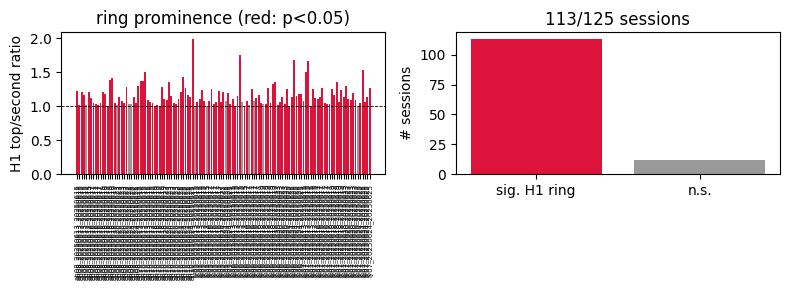

In [5]:
if len(df):
    wdf = df[df.state == 'wake'].reset_index(drop=True)
    fig, ax = plt.subplots(1, 2, figsize=(8, 3))
    x = np.arange(len(wdf))
    cols = ['crimson' if p < 0.05 else '0.6' for p in wdf['H1_p'].fillna(1)]
    ax[0].bar(x, wdf['H1_ratio'], color=cols)
    ax[0].axhline(1, ls='--', color='k', lw=0.6)
    ax[0].set_xticks(x); ax[0].set_xticklabels(wdf['mouse_recday'], rotation=90, fontsize=5)
    ax[0].set_ylabel('H1 top/second ratio'); ax[0].set_title('ring prominence (red: p<0.05)')
    n_sig = int((wdf['H1_p'] < 0.05).sum())
    ax[1].bar(['sig. H1 ring', 'n.s.'], [n_sig, len(wdf) - n_sig], color=['crimson', '0.6'])
    ax[1].set_ylabel('# sessions'); ax[1].set_title(f'{n_sig}/{len(wdf)} sessions')
    fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig2_betti_summary', SAVE_DIR)
    plt.show()

## Fig 3 — Circular coordinate vs behaviour

Does the decoded neural angle θ track the **circular task phase** (and goal
progress / head direction)? `R` = reflection-aware resultant length (1 = perfect,
~0 = chance); `p` from circular-shift shuffles.

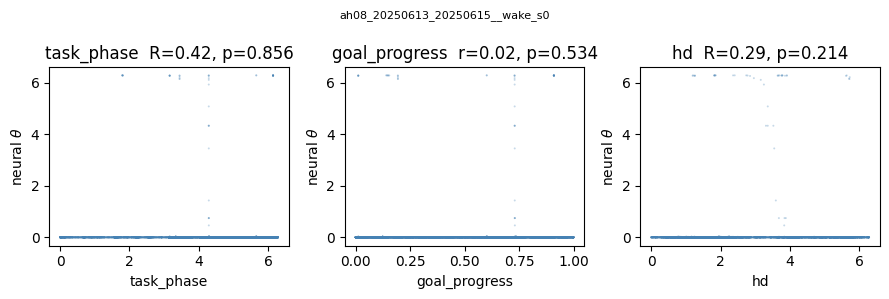

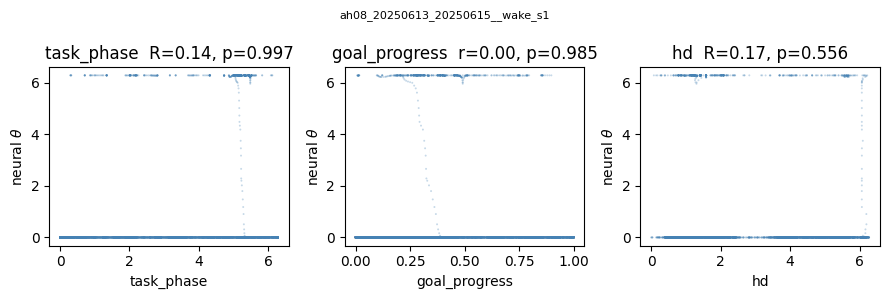

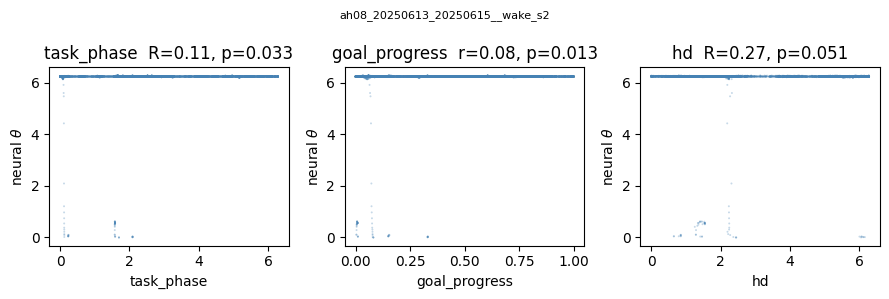

In [6]:
for stem, res in list(wake.items())[:MAX_PLOT]:
    if 'theta' not in res:
        continue
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    ph.plot_coord_vs_behaviour(res, 'task_phase',   ax=axes[0])
    ph.plot_coord_vs_behaviour(res, 'goal_progress', ax=axes[1], circular=False)
    ph.plot_coord_vs_behaviour(res, 'hd',           ax=axes[2])
    fig.suptitle(stem, fontsize=8); fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig3_coord_'+stem, SAVE_DIR)
    plt.show()

## Fig 4 — Manifold embedding (PCA cloud coloured by θ and task phase)

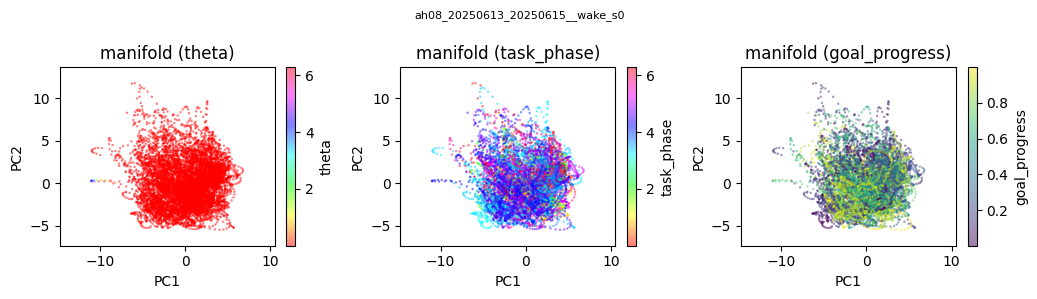

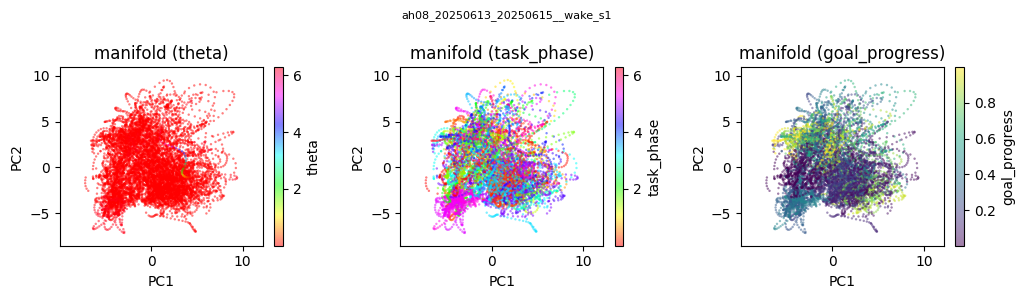

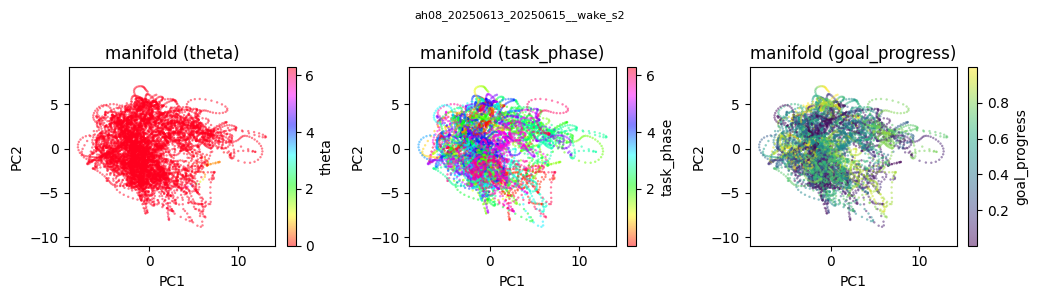

In [7]:
for stem, res in list(wake.items())[:MAX_PLOT]:
    if res.get('_X') is None:
        continue
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3))
    ph.plot_manifold(res, color_by='theta',         ax=axes[0])
    ph.plot_manifold(res, color_by='task_phase',    ax=axes[1])
    ph.plot_manifold(res, color_by='goal_progress', ax=axes[2])
    fig.suptitle(stem, fontsize=8); fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig4_manifold_'+stem, SAVE_DIR)
    plt.show()

## Fig 5 — Sleep: de novo topology + projection onto the wake ring

Left/middle: persistence + significance of the sleep cloud on its own.
Right: the wake circular coordinate decoded over sleep time — coherent cyclic
sweeps (high coherence, p small) indicate the manifold is traversed during
sleep (replay-like).

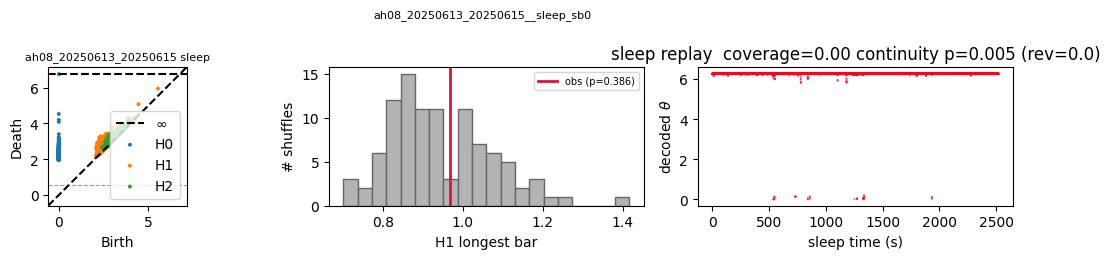

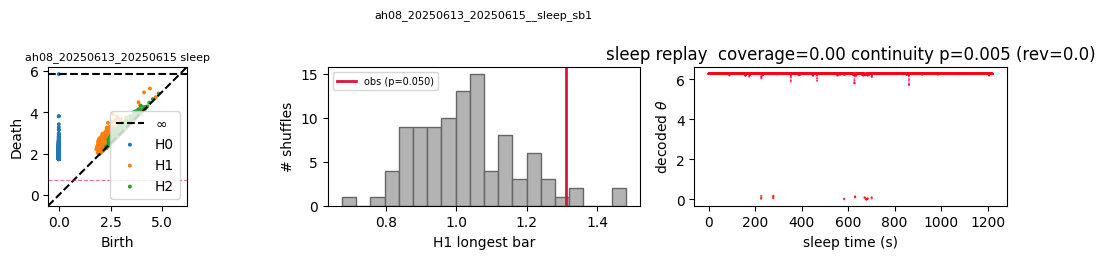

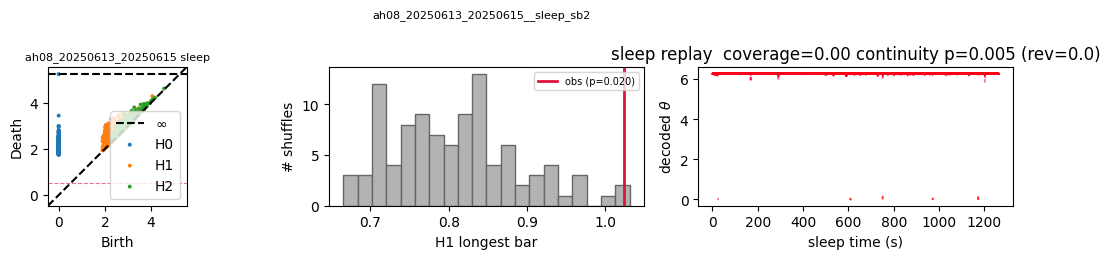

In [8]:
for stem, res in list(sleep.items())[:MAX_PLOT]:
    fig, axes = plt.subplots(1, 3, figsize=(11, 2.6))
    ph.plot_persistence(res, ax=axes[0])
    ph.plot_significance(res, dim=1, ax=axes[1])
    ph.plot_sleep_replay(res, ax=axes[2])
    fig.suptitle(stem, fontsize=8); fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig5_sleep_'+stem, SAVE_DIR)
    plt.show()

## Fig 6 — Wake vs sleep topology comparison

In [9]:
cols = ['mouse_recday', 'state', 'n_points', 'H1_top', 'H1_ratio', 'H1_p',
        'H2_top', 'H2_ratio']
extra = [c for c in ('task_phase_R', 'task_phase_p', 'replay_coverage', 'replay_p_continuity',
                     'net_revolutions') if c in df.columns]
df[cols + extra]

,mouse_recday,state,n_points,H1_top,H1_ratio,H1_p,H2_top,H2_ratio,task_phase_R,task_phase_p,replay_coverage,replay_p_continuity,net_revolutions
0,ah08_20250613_20250615,sleep,25192,0.968730,1.041895,0.386139,0.563337,1.034329,NaN,NaN,0.000097,0.004975,0.000112
1,ah08_20250613_20250615,sleep,12213,1.310856,1.177032,0.049505,0.511260,1.115635,NaN,NaN,0.000226,0.004975,0.000102
2,ah08_20250613_20250615,sleep,12641,1.023584,1.026655,0.019802,0.650744,1.102599,NaN,NaN,0.000062,0.004975,0.000043
3,ah08_20250613_20250615,sleep,12117,1.046605,1.165244,0.306931,0.619772,1.232107,NaN,NaN,0.000326,0.004975,0.000121
4,ah08_20250613_20250615,sleep,13160,0.997042,1.166314,0.158416,0.481347,1.011918,NaN,NaN,0.000532,0.004975,0.000060
...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,ly07_20250624_20250625,wake,9371,1.090752,1.044663,0.039604,0.585247,1.008576,0.147306,0.773227,NaN,NaN,NaN
368,ly07_20250624_20250625,wake,9410,1.179022,1.528851,0.009901,0.511557,1.070538,0.170700,0.441558,NaN,NaN,NaN
369,ly07_20250624_20250625,wake,9202,1.149264,1.067851,0.019802,0.554645,1.118070,0.201874,0.937063,NaN,NaN,NaN
370,ly07_20250624_20250625,wake,10328,0.970262,1.132298,0.019802,0.640443,1.194184,0.084009,0.883117,NaN,NaN,NaN


## Diagnostic — smoothing sweep (live, one raw file)

The task cycle is slow (~tens of seconds), so the ring (if present) emerges only
once smoothing passes the fast spiking noise. This sweeps the smoothing kernel on
a single raw recording and reports the H1 prominence — handy for choosing
`smooth_sigma_bins` / `bin_ms`.

In [10]:
raw_file = '../data/processed_data/neuron_raw_mingyutest/Neuron_raw_ah08_20250613_20250615_0.npy'
raw = np.load(raw_file, allow_pickle=True)
print(f'{"sigma_ms":>9} {"PC1-3var":>9} {"H1ratio":>8} {"H1top":>7}')
for sig in (2, 4, 8, 16, 32):
    cfg = ph.PHConfig(n_landmarks=600, coeff_fields=(2,), maxdim=1,
                      smooth_sigma_bins=sig, speed_filter_wake=False)
    X, _, model = ph.build_point_cloud(raw, cfg)
    s = ph.compute_persistence(X, cfg)['summary'][2][1]
    ev = model['pca'].explained_variance_ratio_[:3].sum()
    print(f'{sig*cfg.bin_ms:>9.0f} {ev:>9.2f} {s["gap_ratio"]:>8.2f} {s["top"]:>7.3f}')

 sigma_ms  PC1-3var  H1ratio   H1top


      200      0.12     1.01   1.015


      400      0.15     1.05   1.003


      800      0.18     1.12   1.683


     1600      0.22     1.06   1.853


     3200      0.27     1.22   3.220


## Fig 7 — Task-phase ring (trial-averaged) — the complementary test

Each point is one **task-phase bin** of the trial-averaged `Neurons_norm`
(360 = 4 states x 90 bins). Only 360 points, so **no landmarks / subsampling /
density trimming** — structurally immune to the outlier-arm artifact that made the
instantaneous clouds produce false H1 bars.

**Read `top/diam`, not H1.** The averaged trajectory is a *closed curve by
construction* (the task cycles A->B->C->D->A), so H1=1 is trivial. The
theoretically-calibrated criterion is `top_over_diameter` = H1 top bar / diameter:

| | top/diam | coverage |
|---|---|---|
| ideal circle (theory) | **0.87** | 1.0 |
| synthetic true S1 ring | **0.83** | 0.88 |
| synthetic ramp (open arc, no hole) | 0.15 | **0.70** &larr; coverage alone is NOT sufficient |
| synthetic pure noise | 0.08 | 0.01 |

Two traps this section documents: **coverage alone can't prove a ring** (an open
ramp scores 0.70), and **phase-smoothing is a trap** — it lifts *noise* to
top/diam 0.47-0.66, tracking the real data, so `phase_smooth_bins=0` is the
default and any increase demands recalibrating the noise control.

129 session rings


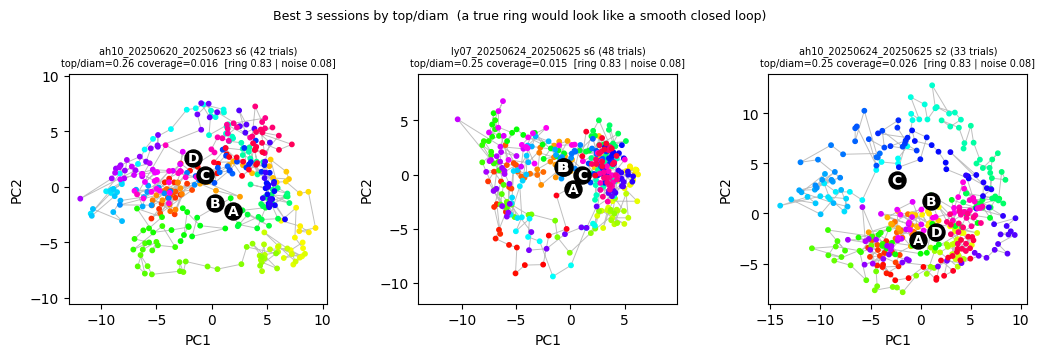

In [11]:
# Task-phase rings (written by run_taskphase_ring.py)
rings = {k: v for k, v in ph.load_ph_outputs(OUT_DIR).items() if v.get('state') == 'ring'}
print(f'{len(rings)} session rings')
if rings:
    best = sorted(rings.values(), key=lambda r: -r['geometry']['top_over_diameter'])[:3]
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))
    for ax, r in zip(axes, best):
        ph.plot_taskphase_ring(r, ax=ax)
    fig.suptitle('Best 3 sessions by top/diam  (a true ring would look like a smooth closed loop)',
                 fontsize=9)
    fig.tight_layout(); plt.show()

top/diam : median 0.097  max 0.260   [true ring 0.83 | noise 0.08]
ring-like (top/diam > 0.5): 0/129


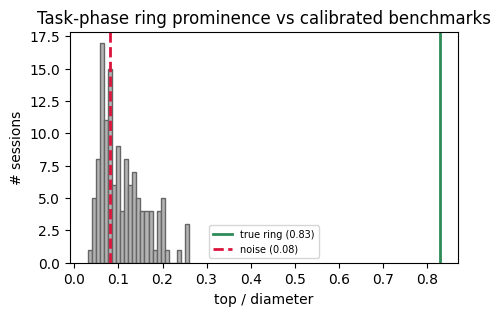

,mouse_recday,session,n_neurons,n_trials,top_over_diam,coverage,alignment,pc12_frac
46,ah10_20250620_20250623,6,153,42,0.260473,0.016258,0.023000,0.546891
127,ly07_20250624_20250625,6,86,48,0.254113,0.014998,0.015876,0.609076
48,ah10_20250624_20250625,2,164,33,0.251761,0.026392,0.034517,0.561112
24,ah10_20250613_20250615,1,139,42,0.235753,0.023854,0.033272,0.518199
33,ah10_20250616_20250617,5,154,25,0.206980,0.015837,0.017453,0.499729
44,ah10_20250620_20250623,4,153,31,0.204168,0.016265,0.016854,0.542978
57,ly05_20250616_20250617,0,116,28,0.203910,0.011467,0.012426,0.588658
41,ah10_20250620_20250623,1,153,26,0.200428,0.012893,0.013034,0.572684
3,ah08_20250613_20250615,5,151,21,0.199790,0.008424,0.009199,0.503804
40,ah10_20250618_20250619,6,162,31,0.196872,0.023829,0.028047,0.552110


In [12]:
# cross-session summary vs the calibrated benchmarks
if rings:
    import pandas as pd
    df_ring = pd.DataFrame([dict(mouse_recday=r['mouse_recday'], session=r['session'],
                                 n_neurons=r['n_neurons'], n_trials=r['n_trials'],
                                 top_over_diam=r['geometry']['top_over_diameter'],
                                 coverage=r['coverage'], alignment=r['alignment'],
                                 pc12_frac=r['geometry']['pc12_frac'])
                            for r in rings.values()]).sort_values('top_over_diam', ascending=False)
    td = df_ring['top_over_diam'].values
    print(f"top/diam : median {np.median(td):.3f}  max {td.max():.3f}   [true ring 0.83 | noise 0.08]")
    print(f"ring-like (top/diam > 0.5): {(td > 0.5).sum()}/{len(td)}")
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.hist(td, bins=25, color='0.7', edgecolor='0.4')
    ax.axvline(0.83, color='seagreen', lw=2, label='true ring (0.83)')
    ax.axvline(0.08, color='crimson', lw=2, ls='--', label='noise (0.08)')
    ax.set_xlabel('top / diameter'); ax.set_ylabel('# sessions')
    ax.set_title('Task-phase ring prominence vs calibrated benchmarks'); ax.legend(fontsize=7)
    plt.show()
    display(df_ring.head(10))

---
### Interpretation guide
- **Significant H1 ring**: one H1 bar with high top/second ratio **and** `H1_p < 0.05`
  vs the per-neuron circular-shift null. The decoded θ should track `task_phase`
  (`task_phase_R` high, `p` small) for the ring to be the *task* ring.
- **Torus**: two long H1 bars **and** a long H2 bar (`H2_ratio ≫ 1`) — rerun the
  batch with the toroidal-coordinate path if this appears.
- **Sleep preservation / replay**: sleep θ(t) moves smoothly
  (`replay_p_continuity < 0.05`) **and** actually explores the ring
  (`replay_coverage` well above 0) ⇒ the wake manifold is
  traversed during sleep.
- A flat barcode (ratios ≈ 1, `H1_p` n.s.) is the honest **null result**: no
  low-dimensional ring in instantaneous activity at these settings.